<a href="https://colab.research.google.com/github/nielitropar/computer-vision/blob/main/Computer_Vision_with_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Computer Vision with Deep Learning

**Instructor:** Dr. Sarwan Singh, NIELIT Deemed to be University, Main Campus Ropar

---

## Recap from Part 1
In the previous session, we learned:
- How images are stored as matrices of pixel values
- Color space conversions (BGR → RGB → Grayscale)
- Classical edge detection using Canny algorithm
- Traditional ML-based face detection using Haar Cascades
- Introduction to YOLO for real-time object detection

## What We Will Cover Today
1. **Why Deep Learning for Vision?** — Limitations of classical CV
2. **Convolutional Neural Networks (CNNs)** — How they "see"
3. **Image Classification** — Classifying images with a pre-trained CNN (ResNet)
4. **Transfer Learning** — Training on your own data using a pretrained backbone
5. **Semantic Segmentation** — Pixel-level understanding with a pretrained model
6. **Practical Challenge** — Build your own mini image classifier

---

In [1]:
# Install & Import

# Install any extra libraries we need (torch is pre-installed in Colab)
# !pip install torchvision -q  # Usually already available in Colab

import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import torch.nn as nn
import torch.optim as optim

import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from PIL import Image
import json

# Check if GPU is available — this matters a lot for training speed!
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Setup complete! Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Setup complete! Using device: cuda
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


# SECTION 1: Why Deep Learning for Vision?

## 1. Why Deep Learning for Vision?

Classical computer vision (like what we did in Part 1) relies on **hand-crafted features**:
- Canny edges: manually chosen thresholds
- Haar Cascades: manually designed templates for face patterns

The fundamental problem: **These features are designed by humans and are brittle.**
- Canny fails under poor lighting
- Haar Cascades fail with side-facing, occluded, or unusual faces

### The Deep Learning Revolution (2012 — ImageNet Moment)
In 2012, AlexNet (a CNN) crushed the competition on the ImageNet challenge,
reducing the top-5 error rate from ~26% to ~15%. This was a watershed moment.

Why CNNs work:
- They learn features automatically from data (no manual engineering!)
- They learn hierarchical representations:
  - Early layers → Edges, blobs, gradients
  - Middle layers → Textures, patterns
  - Deep layers → Object parts, faces, wheels, eyes...

Let's visualize this concept before we build one.

/tmp/ipykernel_12720/260540177.py:30: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  axes[2].add_patch(Ellipse((20, 70), 30, 15, color='#16213e', alpha=0.9, edgecolor='white'))


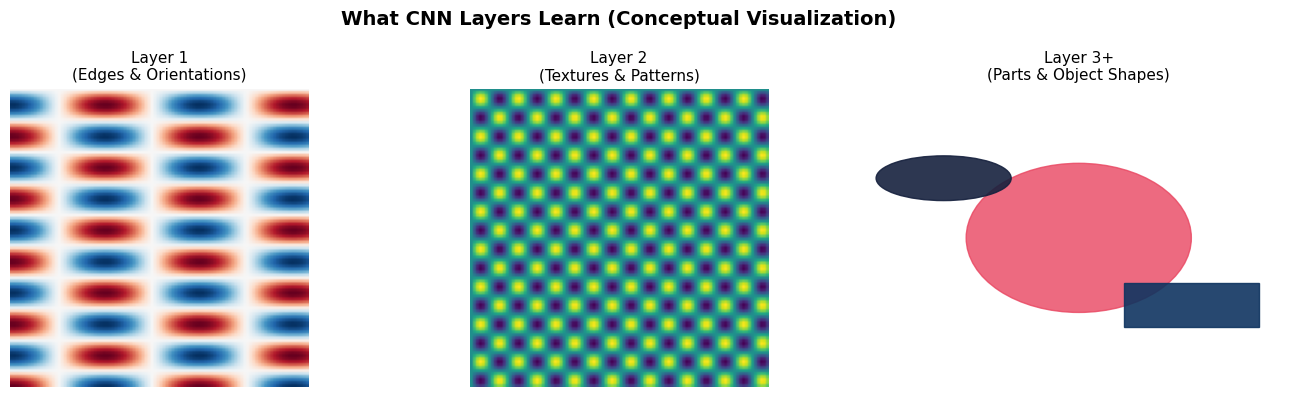

In [2]:
# Visualize what different CNN "layers" conceptually detect
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("What CNN Layers Learn (Conceptual Visualization)", fontsize=14, fontweight='bold')

# Layer 1: Simple edges/orientations (Gabor-like filters as proxy)
layer1 = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        layer1[i, j] = np.sin(i * 0.3) * np.cos(j * 0.1)

axes[0].imshow(layer1, cmap='RdBu')
axes[0].set_title("Layer 1\n(Edges & Orientations)", fontsize=11)
axes[0].axis('off')

# Layer 2: Texture-like patterns
layer2 = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        layer2[i, j] = np.sin(i * 0.5) * np.sin(j * 0.5)

axes[1].imshow(layer2, cmap='viridis')
axes[1].set_title("Layer 2\n(Textures & Patterns)", fontsize=11)
axes[1].axis('off')

# Layer 3: Abstract shapes
from matplotlib.patches import Circle, Rectangle, Ellipse
axes[2].set_facecolor('#1a1a2e')
axes[2].add_patch(Circle((50, 50), 25, color='#e94560', alpha=0.8))
axes[2].add_patch(Rectangle((60, 20), 30, 15, color='#0f3460', alpha=0.9))
axes[2].add_patch(Ellipse((20, 70), 30, 15, color='#16213e', alpha=0.9, edgecolor='white'))
axes[2].set_xlim(0, 100)
axes[2].set_ylim(0, 100)
axes[2].set_title("Layer 3+\n(Parts & Object Shapes)", fontsize=11)
axes[2].axis('off')

plt.tight_layout()
plt.show()

# SECTION 2: Anatomy of a CNN

## 2. Anatomy of a CNN (Convolutional Neural Network)

A CNN is made of stacked layers:

| Layer Type         | What It Does                                                  |
|--------------------|---------------------------------------------------------------|
| **Conv2D**         | Applies a learnable filter (kernel) that slides across image |
| **ReLU**           | Activation function — adds non-linearity                     |
| **MaxPooling2D**   | Downsamples: keeps the max value in each region              |
| **Flatten**        | Converts 2D feature maps to a 1D vector                     |
| **Fully Connected**| Standard neural network layers for final classification      |
| **Softmax**        | Converts raw scores to probabilities (for classification)    |

Let's manually demonstrate what a convolution does to an image.

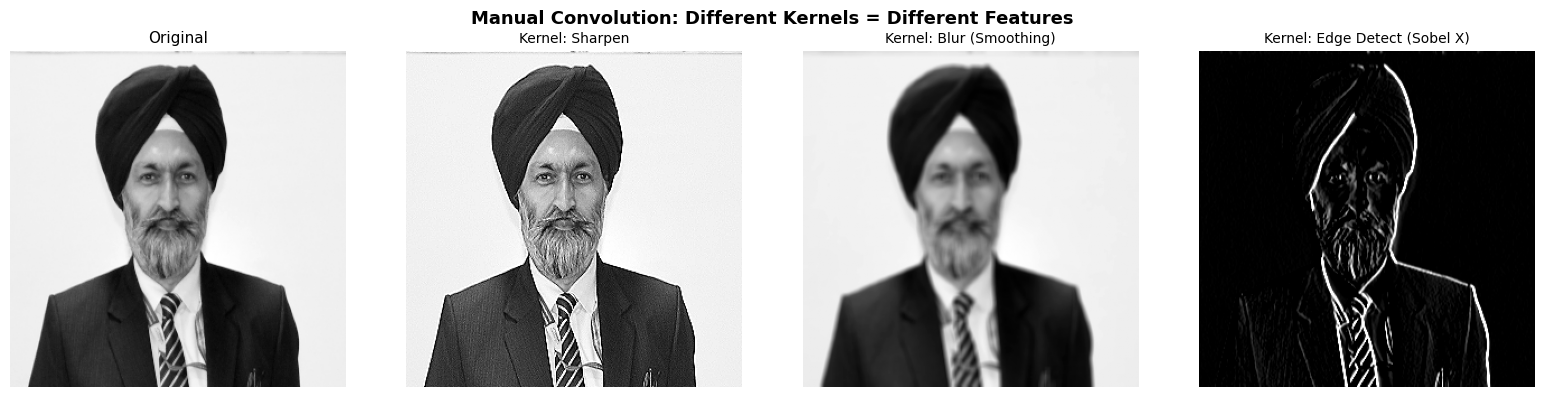

Key insight: In a CNN, kernels like these are NOT hand-crafted.
They are LEARNED from training data using backpropagation!


In [3]:
# Manually demonstrate convolution
# Download a sample image
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/nielitropar/computer-vision/refs/heads/main/assets/Sarwan_Singh.JPG",
    "sample.jpg"
)

img = cv2.imread("sample.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (300, 300))

# Define three different kernels
kernels = {
    "Sharpen": np.array([[0, -1, 0],
                          [-1, 5, -1],
                          [0, -1, 0]], dtype=np.float32),

    "Blur (Smoothing)": np.ones((5, 5), dtype=np.float32) / 25,

    "Edge Detect (Sobel X)": np.array([[-1, 0, 1],
                                        [-2, 0, 2],
                                        [-1, 0, 1]], dtype=np.float32)
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original", fontsize=11)
axes[0].axis('off')

for ax, (name, kernel) in zip(axes[1:], kernels.items()):
    filtered = cv2.filter2D(img, -1, kernel)
    ax.imshow(filtered, cmap='gray')
    ax.set_title(f"Kernel: {name}", fontsize=10)
    ax.axis('off')

fig.suptitle("Manual Convolution: Different Kernels = Different Features", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key insight: In a CNN, kernels like these are NOT hand-crafted.")
print("They are LEARNED from training data using backpropagation!")

# SECTION 3: Image Classification with a Pretrained ResNet

## 3. Image Classification with Pretrained ResNet-50

Training a CNN from scratch needs millions of images and days of compute.
Instead, we use **pretrained models** — CNNs already trained on ImageNet
(1.2 million images, 1000 categories).

**ResNet-50** (Residual Network, 50 layers) is a landmark architecture.
Its key innovation: **skip connections** that allow very deep networks
to train without the vanishing gradient problem.

We will:
1. Load ResNet-50 with pretrained ImageNet weights
2. Preprocess our image (resize, normalize — must match training conditions)
3. Run inference and decode the top-5 predictions

Loading ResNet-50 (pretrained on ImageNet)...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 143MB/s]


ResNet-50 loaded successfully!
Loaded 1000 ImageNet class labels.

 Top-5 Predictions for our image:
---------------------------------------------
  #1  suit                           20.76%
  #2  wool                           7.40%
  #3  Windsor tie                    6.18%
  #4  academic gown                  1.01%
  #5  swimming cap                   0.79%


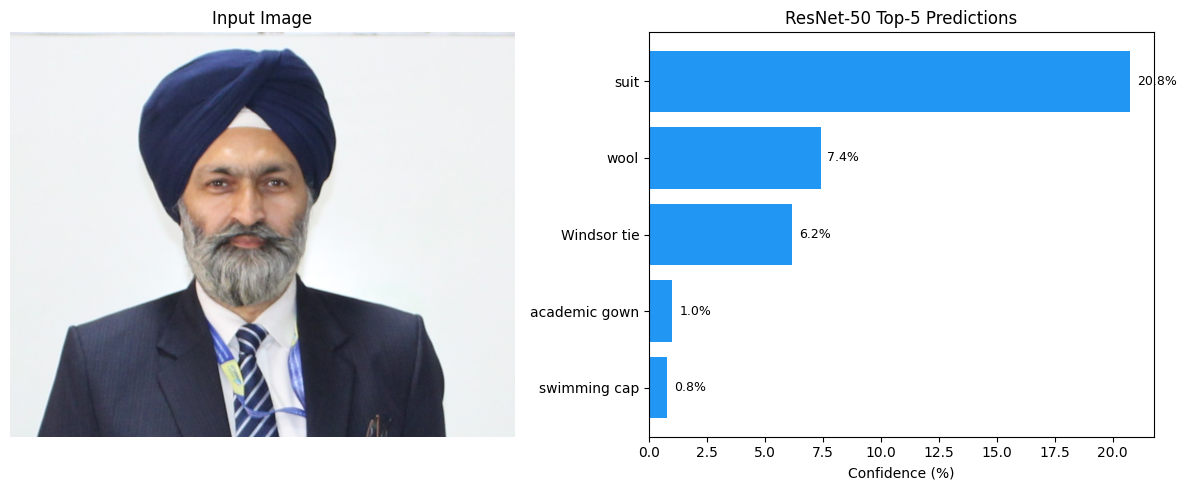

In [4]:
# Load pretrained ResNet-50
print("Loading ResNet-50 (pretrained on ImageNet)...")
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
resnet = resnet.to(device)
resnet.eval()  # Set to evaluation mode (disables dropout, batch norm uses stored stats)
print("ResNet-50 loaded successfully!")

# Preprocessing pipeline — MUST match what the model was trained with
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),         # ResNet expects 224×224 input
    transforms.ToTensor(),              # Convert to [0, 1] float tensor
    transforms.Normalize(               # Normalize with ImageNet mean & std
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Download ImageNet class labels
labels_url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
urllib.request.urlretrieve(labels_url, "imagenet_labels.json")
with open("imagenet_labels.json") as f:
    imagenet_labels = json.load(f)

print(f"Loaded {len(imagenet_labels)} ImageNet class labels.")

# Classify our sample image
pil_img = Image.open("sample.jpg").convert("RGB")
input_tensor = preprocess(pil_img).unsqueeze(0).to(device)  # Add batch dimension

with torch.no_grad():   # No gradient computation needed during inference
    output = resnet(input_tensor)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)

# Get top-5 predictions
top5_prob, top5_idx = torch.topk(probabilities, 5)
top5_prob = top5_prob.cpu().numpy()
top5_idx = top5_idx.cpu().numpy()

# Display results
print("\n Top-5 Predictions for our image:")
print("-" * 45)
for i, (prob, idx) in enumerate(zip(top5_prob, top5_idx)):
    label = imagenet_labels[idx] if idx < len(imagenet_labels) else f"class_{idx}"
    print(f"  #{i+1}  {label:<30} {prob*100:.2f}%")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(pil_img)
ax1.set_title("Input Image", fontsize=12)
ax1.axis('off')

labels_plot = [imagenet_labels[i] if i < len(imagenet_labels) else f"class_{i}" for i in top5_idx]
bars = ax2.barh(labels_plot[::-1], top5_prob[::-1] * 100, color='#2196F3')
ax2.set_xlabel("Confidence (%)")
ax2.set_title("ResNet-50 Top-5 Predictions", fontsize=12)
for bar, prob in zip(bars, top5_prob[::-1]):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{prob*100:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# SECTION 4: Transfer Learning - Train on Custom Data

## 4. Transfer Learning - Teaching ResNet New Tricks

**Core Idea:** A model trained on 1.2M images has already learned to detect
edges, textures, shapes, eyes, fur, wheels, etc. These features are universal!

Transfer Learning:
1. Take a pretrained model (e.g., ResNet-50)
2. **Freeze** the early layers (they already know general features)
3. **Replace** the final classification head with one for YOUR classes
4. **Fine-tune** only the last few layers on your dataset

This lets you train on even 100–500 images per class and get great results!

### Practical Example: Binary Classifier (Cats vs. Dogs subset)
We'll demonstrate the architecture and training loop.
In your assignment, you'll apply this to your own dataset.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]


Total parameters:     11,308,354
Trainable parameters: 131,842  (1.2% of model)

 We're only training 1.2% of parameters — very efficient!


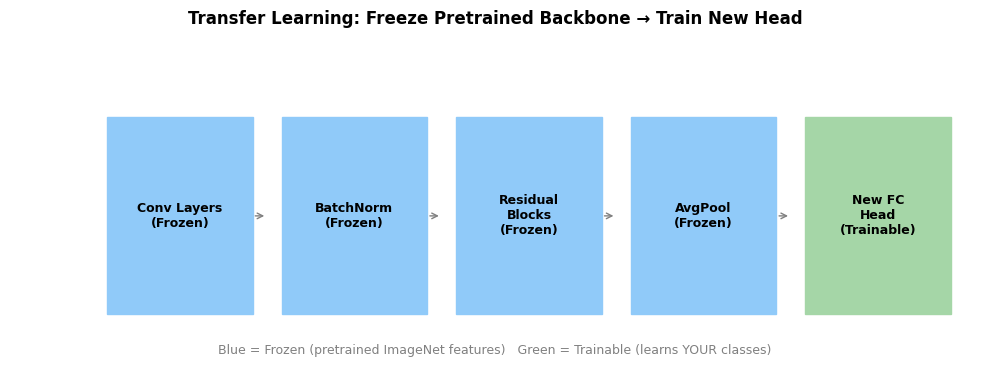

In [5]:
# Build a Transfer Learning model
# Load ResNet-18 (lighter than ResNet-50 for faster demo)
model_tl = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# model_tl = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Step 1: Freeze ALL layers
for param in model_tl.parameters():
    param.requires_grad = False

# Step 2: Replace the final fully connected layer
# ResNet-18's final layer outputs 512 features → we change to 2 (cats/dogs)
num_classes = 2  # cats, dogs
model_tl.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)
# Only the new fc layer's parameters have requires_grad=True
model_tl = model_tl.to(device)

# Count trainable vs frozen parameters
total_params = sum(p.numel() for p in model_tl.parameters())
trainable_params = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}  ({100*trainable_params/total_params:.1f}% of model)")
print(f"\n We're only training {100*trainable_params/total_params:.1f}% of parameters — very efficient!")

# Visualize the architecture modification
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
layers_info = [
    ("Conv Layers\n(Frozen)", "#90CAF9", 0.1),
    ("BatchNorm\n(Frozen)", "#90CAF9", 0.28),
    ("Residual\nBlocks\n(Frozen)", "#90CAF9", 0.46),
    ("AvgPool\n(Frozen)", "#90CAF9", 0.64),
    ("New FC\nHead\n(Trainable)", "#A5D6A7", 0.82),
]
for label, color, x in layers_info:
    rect = plt.Rectangle((x, 0.2), 0.15, 0.6, color=color, transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(x + 0.075, 0.5, label, ha='center', va='center',
            transform=ax.transAxes, fontsize=9, fontweight='bold')
    if x < 0.82:
        ax.annotate("", xy=(x + 0.165, 0.5), xytext=(x + 0.15, 0.5),
                    xycoords='axes fraction', arrowprops=dict(arrowstyle="->", color='gray'))

ax.set_title("Transfer Learning: Freeze Pretrained Backbone → Train New Head",
             fontsize=12, fontweight='bold', pad=20)
ax.text(0.5, 0.08, "Blue = Frozen (pretrained ImageNet features)   Green = Trainable (learns YOUR classes)",
        ha='center', transform=ax.transAxes, fontsize=9, color='gray')
plt.tight_layout()
plt.show()

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
# Only optimize the new fc layer
optimizer = optim.Adam(model_tl.fc.parameters(), lr=0.001)

# Simulated Training Loop (structure — real training needs a dataset)

## In a real scenario, you would:

```
Organize your data:

data/
├── train/
│   ├── cats/   # image files
│   └── dogs/   # image files
└── val/
├── cats/
└── dogs/

````

---

## Loading Data with `ImageFolder` and `DataLoader`

```python
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms

# Define preprocessing pipeline
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load dataset
train_dataset = ImageFolder("data/train", transform=preprocess)

# Create DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
````

---

## Training Loop

```python
for epoch in range(num_epochs):
    model_tl.train()
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_tl(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {loss.item():.4f}")
```

---

## Simulating a Loss Curve (Convergence Visualization)

```python
import matplotlib.pyplot as plt
import numpy as np

# Simulated loss values (monotonically decreasing with noise)
epochs = 20
loss_values = np.exp(-0.2 * np.arange(epochs)) + 0.05 * np.random.rand(epochs)

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), loss_values, marker='o')
plt.title("Simulated Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()
```

---

## What Convergence Looks Like

* Loss decreases consistently across epochs
* Early epochs: steep decline
* Later epochs: gradual flattening
* Small fluctuations due to stochastic updates

If the curve:

* **Flattens too early** → underfitting
* **Oscillates heavily** → learning rate too high
* **Decreases then increases** → overfitting

---




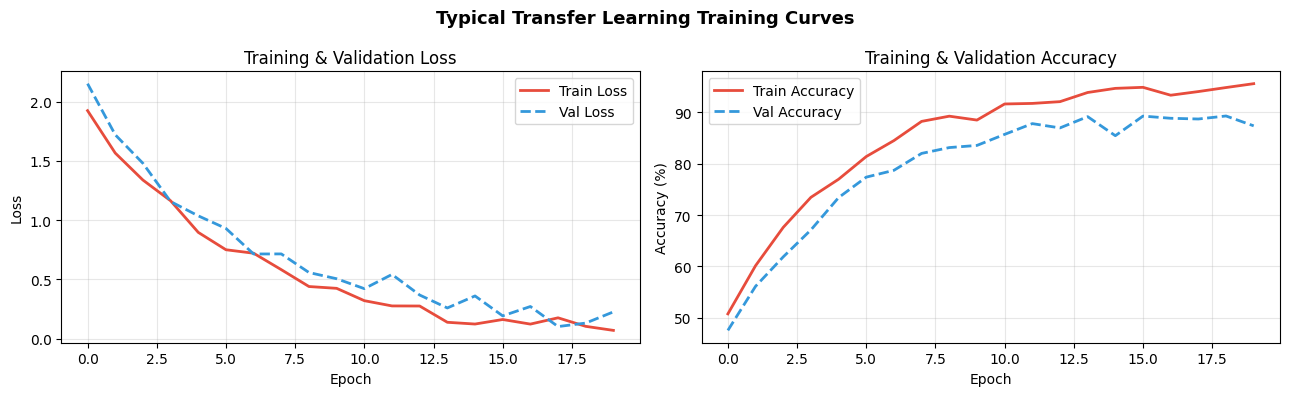

Watch for: Val loss rising while Train loss keeps falling = Overfitting!
Solution: Early stopping, dropout, data augmentation, weight decay.


In [6]:
# Simulate training loss curve to visualize concept
np.random.seed(42)
epochs = 20
# Simulated loss curves
train_loss = [1.8 * np.exp(-0.2 * e) + 0.1 + 0.05 * np.random.randn() for e in range(epochs)]
val_loss = [1.9 * np.exp(-0.18 * e) + 0.15 + 0.07 * np.random.randn() for e in range(epochs)]
train_acc = [50 + 45 * (1 - np.exp(-0.25 * e)) + np.random.randn() for e in range(epochs)]
val_acc = [48 + 42 * (1 - np.exp(-0.22 * e)) + np.random.randn() for e in range(epochs)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(train_loss, label='Train Loss', color='#e74c3c', linewidth=2)
ax1.plot(val_loss, label='Val Loss', color='#3498db', linewidth=2, linestyle='--')
ax1.set_title("Training & Validation Loss", fontsize=12)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(train_acc, label='Train Accuracy', color='#e74c3c', linewidth=2)
ax2.plot(val_acc, label='Val Accuracy', color='#3498db', linewidth=2, linestyle='--')
ax2.set_title("Training & Validation Accuracy", fontsize=12)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(alpha=0.3)

fig.suptitle("Typical Transfer Learning Training Curves", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Watch for: Val loss rising while Train loss keeps falling = Overfitting!")
print("Solution: Early stopping, dropout, data augmentation, weight decay.")

# SECTION 5: Data Augmentation

## 5. Data Augmentation - Getting More from Less Data

A CNN needs many diverse examples to generalize. But collecting thousands
of labeled images is expensive. Data Augmentation artificially expands
your dataset by applying random transformations to existing images.

**The rule:** Augment only the TRAINING set, not the validation/test set.

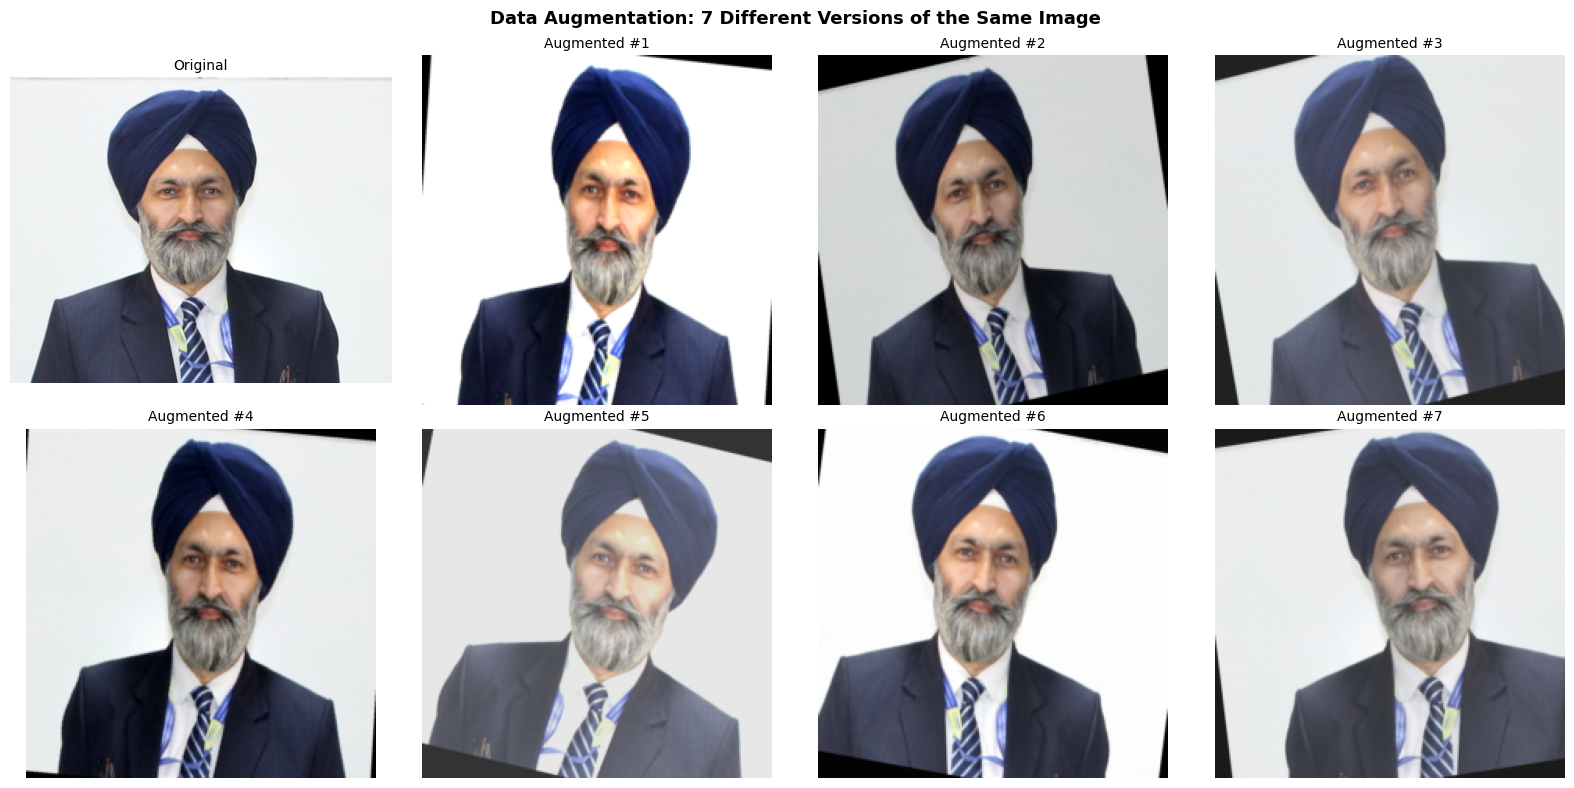

At each training epoch, the model sees slightly different versions.
 This prevents memorization and improves generalization!


In [7]:
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
])

pil_img_rgb = Image.open("sample.jpg").convert("RGB")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Data Augmentation: 7 Different Versions of the Same Image", fontsize=13, fontweight='bold')

axes[0][0].imshow(pil_img_rgb)
axes[0][0].set_title("Original", fontsize=10)
axes[0][0].axis('off')

for i, ax in enumerate(axes.flat[1:]):
    augmented = aug_transform(pil_img_rgb)
    ax.imshow(augmented)
    ax.set_title(f"Augmented #{i+1}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("At each training epoch, the model sees slightly different versions.")
print(" This prevents memorization and improves generalization!")

# SECTION 6: Semantic Segmentation (Intro)

## 6. Semantic Segmentation - Pixel-Level Understanding

So far we've done:
- **Classification**: What is in this image? → "cat" (one label for whole image)
- **Detection (YOLO, Part 1)**: Where is it? → Bounding boxes around objects

Now: **Segmentation**: What is at every single pixel?
- Every pixel gets labeled (sky, road, person, car, building...)

This is crucial for: self-driving cars, medical imaging, satellite analysis.

**DeepLab / FCN (Fully Convolutional Network)** are popular architectures.
Let's use a pretrained segmentation model from torchvision.

Loading pretrained segmentation model (FCN-ResNet50)...
Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth


100%|██████████| 135M/135M [00:02<00:00, 50.4MB/s]


Segmentation model loaded!

🔍 Detected regions: ['background', 'person']


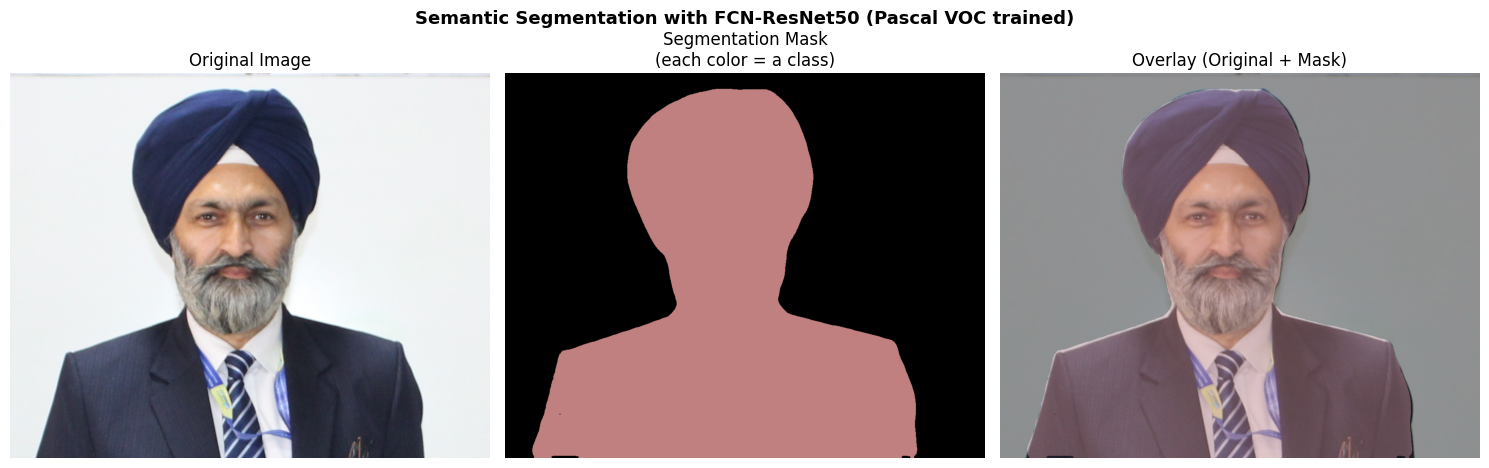

In [8]:
# Load pretrained FCN-ResNet50 segmentation model
print("Loading pretrained segmentation model (FCN-ResNet50)...")
seg_model = models.segmentation.fcn_resnet50(
    weights=models.segmentation.FCN_ResNet50_Weights.DEFAULT
)
seg_model = seg_model.to(device)
seg_model.eval()
print("Segmentation model loaded!")

# Pascal VOC 21 class labels + colors
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse',
    'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
VOC_COLORS = np.array([
    [0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0], [0, 0, 128],
    [128, 0, 128], [0, 128, 128], [128, 128, 128], [64, 0, 0], [192, 0, 0],
    [64, 128, 0], [192, 128, 0], [64, 0, 128], [192, 0, 128], [64, 128, 128],
    [192, 128, 128], [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
    [0, 64, 128]
], dtype=np.uint8)

# Preprocessing for segmentation
seg_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

input_seg = seg_transform(pil_img_rgb).unsqueeze(0).to(device)

with torch.no_grad():
    output_seg = seg_model(input_seg)['out']

# Get predicted class for each pixel
pred_mask = output_seg.argmax(dim=1).squeeze().cpu().numpy()

# Map class indices to colors
color_mask = VOC_COLORS[pred_mask]

# Detected classes
unique_classes = np.unique(pred_mask)
detected = [VOC_CLASSES[c] for c in unique_classes if c < len(VOC_CLASSES)]
print(f"\n🔍 Detected regions: {detected}")

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(pil_img_rgb)
axes[0].set_title("Original Image", fontsize=12)
axes[0].axis('off')

axes[1].imshow(color_mask)
axes[1].set_title("Segmentation Mask\n(each color = a class)", fontsize=12)
axes[1].axis('off')

# Blend original + mask for overlay
img_arr = np.array(pil_img_rgb.resize((pred_mask.shape[1], pred_mask.shape[0])))
blend = (0.6 * img_arr + 0.4 * color_mask).astype(np.uint8)
axes[2].imshow(blend)
axes[2].set_title("Overlay (Original + Mask)", fontsize=12)
axes[2].axis('off')

fig.suptitle("Semantic Segmentation with FCN-ResNet50 (Pascal VOC trained)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# SECTION 7: Comparing Approaches - Summary Table

## 7. Summary: Classical CV vs. Deep Learning CV

| Task                | Classical Approach        | Deep Learning Approach      |
|---------------------|--------------------------|------------------------------|
| Edge Detection      | Canny (manual threshold) | Learned conv filters         |
| Face Detection      | Haar Cascades            | MTCNN, RetinaFace            |
| Classification      | HOG + SVM                | ResNet, EfficientNet         |
| Object Detection    | Sliding window + HOG     | YOLO, Faster R-CNN           |
| Segmentation        | GrabCut, Watershed       | FCN, DeepLab, SAM            |
| Feature Extraction  | SIFT, ORB                | CNN features (embedding)     |

**When to use classical CV:**
- Very limited data (few images, no GPU)
- Real-time on embedded/edge hardware (Raspberry Pi, microcontrollers)
- Interpretability is required (medical, legal)

**When to use Deep Learning CV:**
- Large labeled dataset available
- GPU available (or cloud compute)
- Maximum accuracy is priority


CLASSICAL CV vs DEEP LEARNING CV — QUICK REFERENCE
============================================================

| Task               | Classical Approach            | Deep Learning Approach              |
|--------------------|------------------------------|------------------------------------|
| Edge Detection     | Canny (manual thresholds)    | Learned convolutional filters       |
| Face Detection     | Haar Cascades                | MTCNN / RetinaFace                 |
| Classification     | HOG + SVM                    | ResNet / EfficientNet              |
| Object Detection   | Sliding Window + HOG         | YOLO / Faster R-CNN                |
| Segmentation       | GrabCut / Watershed          | FCN / DeepLab / SAM                |

---

## Key Differences

### Classical Computer Vision
- Hand-engineered features (HOG, SIFT, etc.)
- Requires domain expertise
- Works well on simple, controlled data
- Limited generalization

### Deep Learning CV
- Learns features automatically from data
- Requires large datasets + compute
- High accuracy and robustness
- End-to-end optimization

---

## Rule of Thumb

- **Low data + simple problem → Classical CV**
- **High data + complex patterns → Deep Learning**

---

# SECTION 8: Assignment / Practical Challenge

## 8. 📝 Assignment — Build Your Own Mini Classifier

**Task:** Use Transfer Learning (ResNet-18) to classify images from a dataset of your choice.

### Instructions:

**Option A (Beginner):** Use the CIFAR-10 dataset (pre-packaged in torchvision)
```python
from torchvision.datasets import CIFAR10
train_data = CIFAR10(root='./data', train=True, download=True, transform=preprocess)
```
Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

**Option B (Intermediate):** Collect 50–100 images each of 2 custom classes
(Example: your college campus vs. another campus, fruits, hand gestures)
Organize in the folder structure shown in Section 4.

**Option C (Advanced):** Apply segmentation to a video file using YOLO-Seg:
```python
from ultralytics import YOLO
model = YOLO("yolo11n-seg.pt")
results = model.predict(source="your_video.mp4", save=True)
```

### Evaluation Criteria:
- [ ] Model trains without errors
- [ ] Achieves >70% validation accuracy (Option A/B)
- [ ] Training curves plotted (loss + accuracy)
- [ ] Confusion matrix generated
- [ ] 5-slide explanation: Problem → Data → Model → Results → Learnings

---


***SESSION COMPLETE!***
============================================================

What you learned today:

- Why CNNs outperform classical CV methods  
- What convolution operations do (manually verified)  
- How to run inference with pretrained ResNet-50  
- Transfer Learning: freeze backbone, train new head  
- Data Augmentation to fight overfitting  
- Semantic Segmentation with FCN-ResNet50  
- When to choose classical CV vs deep learning  

---

## What's Next

- Object Tracking (DeepSORT)  
- Pose Estimation (MediaPipe)  
- Face Recognition (ArcFace embeddings)  
- Building a CV pipeline (end-to-end project)  

---

> **"A model is only as good as the data it learns from.  
> And a CV engineer is only as good as the problems they choose to solve."**  
> — Dr. Sarwan Singh, NIELIT Ropar





---





---



# **Notes: Computer Vision with Deep Learning**

**Course Context:** AI/ML | NIELIT Ropar × IIT Ropar

**Focus:** CNNs, Transfer Learning, Data Augmentation, and Semantic Segmentation.

---

## **1. The Paradigm Shift: Classical vs. Deep Learning**

The fundamental limitation of classical computer vision is the reliance on **hand-crafted features**. Algorithms like Canny (edge detection) or Haar Cascades (face detection) are brittle because human engineers must manually define the operational thresholds and templates.

Deep learning, specifically through Convolutional Neural Networks (CNNs), replaces this with **Representation Learning**. The network learns hierarchical features automatically from the data:
* **Early Layers:** Basic structures (edges, gradients, orientations).
* **Middle Layers:** Complex textures and repeating patterns.
* **Deep Layers:** Semantic object parts (wheels, faces, limbs).

### **Decision Framework**
* **Use Classical CV:** When constrained by low data availability, edge-hardware compute limits, or strict interpretability requirements.
* **Use Deep Learning CV:** When robust accuracy is paramount, complex abstract patterns exist, and sufficient data/compute (GPUs) are available.

---

## **2. Anatomy of a CNN**

CNNs utilize stacked specialized layers to process visual spatial data effectively.

* **Conv2D:** Applies a learnable filter (kernel) via a sliding dot-product operation.
    * *Mathematical Intuition:* $$y(i,j) = \sum_m \sum_n x(i+m, j+n) \cdot k(m,n)$$
    * Where $x$ is the image region and $k$ is the kernel. These kernels are optimized via backpropagation, not manually set.
* **ReLU (Rectified Linear Unit):** Injects non-linearity, preventing the network from collapsing into a simple linear transformation.
    * *Formula:* $$f(x) = \max(0, x)$$
* **MaxPooling2D:** Downsamples the spatial dimensions, retaining dominant features while reducing computational load.
* **Flatten:** Unrolls 2D feature maps into a 1D vector.
* **Fully Connected (FC):** Standard dense layers that map the extracted features to final output classes.

---

## **3. Image Classification & ResNet-50**

Training CNNs from scratch requires massive datasets (e.g., ImageNet's 1.2M images) and heavy compute. Modern workflows utilize **pretrained models** like ResNet-50.

**The ResNet Innovation:**
Deep networks traditionally suffer from the vanishing gradient problem. ResNet solves this using **skip connections** (residual blocks), learning the residual mapping rather than the direct mapping:
$$y = \mathcal{F}(x) + x$$

**The Inference Pipeline:**
1.  **Strict Preprocessing:** Inputs must mathematically match the data distribution the model was originally trained on.
    * Resize to **256x256**, Center crop to **224x224**.
    * Normalize using exact ImageNet parameters (Mean: `[0.485, 0.456, 0.406]`, Std: `[0.229, 0.224, 0.225]`).
2.  **Forward Pass:** Disable gradient tracking (`torch.no_grad()`) to save memory and compute.
3.  **Softmax:** Convert raw logit outputs into a valid probability distribution.
    * *Formula:* $$P_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

---

## **4. Transfer Learning (Fine-Tuning)**

Transfer learning leverages universal features (edges, textures) learned by a model on a massive dataset, adapting them to a new, smaller dataset. This drastically reduces the required training data and compute time.

**The Execution Strategy:**
1.  **Load** a pretrained backbone (e.g., ResNet-18).
2.  **Freeze** the early/middle convolutional layers to preserve the learned feature extractors.
    * *Implementation:* `param.requires_grad = False`
3.  **Replace** the final Fully Connected head to match the new number of target classes.
4.  **Train** only the weights of the new FC layers using a standard optimizer like Adam.

*Efficiency Note:* In a typical transfer learning setup, you may only be actively training **1% to 2%** of the model's total parameters.

---

## **5. Data Augmentation**

Neural networks require massive diversity to generalize well. Data augmentation artificially expands the training set by applying random programmatic transformations to existing images.

* **Common Transformations:** Random Horizontal Flips, Rotations (e.g., 15°), Color Jitter (adjusting brightness, contrast, saturation), and Random Resized Crops.
* **Core Rule:** Augmentation is strictly applied to the **Training Set**. The Validation/Test sets must remain pristine to accurately measure real-world performance.

---

## **6. Training Dynamics & Diagnostics**

Monitoring the loss and accuracy curves across epochs is critical for diagnosing model health.

* **Ideal Convergence:** Both Training Loss and Validation Loss decrease steadily.
* **Overfitting:** Training Loss continues to fall, but Validation Loss begins to rise. The model is memorizing the training data.
    * *Mitigations:* Dropout, stronger data augmentation, weight decay, or early stopping.
* **Underfitting:** Both curves remain high and flatten too early. The model cannot capture the data's complexity.
    * *Mitigations:* Increase model complexity, reduce regularization, or train for more epochs.

---

## **7. Semantic Segmentation**

While classification assigns one label to an entire image, and object detection draws bounding boxes, **Semantic Segmentation** assigns a class label to every single pixel.

* **Common Architectures:** FCN (Fully Convolutional Networks), DeepLab.
* **Mechanism:** The network outputs a tensor where the depth matches the number of possible classes. An `argmax` operation across the class dimension yields a 2D mask mapping each pixel to its highest-probability class index.
* **Use Cases:** Autonomous driving (delineating drivable space vs. pedestrians), precise medical imaging analysis, and satellite terrain mapping.



---



# **How to check for Data Leakage**

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("princelv84/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [10]:
!ls

imagenet_labels.json  sample_data  sample.jpg


In [11]:
# Set seeds for reproducibility
# tf.random.set_seed(42)
# np.random.seed(42)
# random.seed(42)
import os
import random
import shutil
# Define paths and constants
INPUT_DIR = '/kaggle/input/dogsvscats/train'     # Source dataset directory
WORK_DIR = '/content'                       # Working directory
SAMPLE_DIR = os.path.join(WORK_DIR, 'sample')      # Path to hold sampled subset
# IMG_HEIGHT, IMG_WIDTH = 150, 150                   # Image size to resize to
# BATCH_SIZE = 32                                    # Batch size for data generators
# EPOCHS = 20                                        # Number of training epochs

In [12]:
# Prepare a Small Sample Dataset
def prepare_data(src, size=2000):
    """
    Prepare a subset of data with balanced classes for training and validation.
    - 1600 images for training (800 cats, 800 dogs)
    - 400 images for validation (200 cats, 200 dogs)
    """
    folders = ['train/cats', 'train/dogs', 'validation/cats', 'validation/dogs']
    for folder in folders:
        os.makedirs(os.path.join(SAMPLE_DIR, folder), exist_ok=True)

    # List and shuffle filenames
    cats = os.listdir(os.path.join(src, 'cats'))
    dogs = os.listdir(os.path.join(src, 'dogs'))
    random.shuffle(cats)
    random.shuffle(dogs)

    train_n, val_n = int(size * 0.4), int(size * 0.1)

    # Copy training images
    for i in range(train_n):
        shutil.copy(os.path.join(src, 'cats', cats[i]), os.path.join(SAMPLE_DIR, 'train/cats'))
        shutil.copy(os.path.join(src, 'dogs', dogs[i]), os.path.join(SAMPLE_DIR, 'train/dogs'))

    # Copy validation images
    for i in range(val_n):
        shutil.copy(os.path.join(src, 'cats', cats[train_n+i]), os.path.join(SAMPLE_DIR, 'validation/cats'))
        shutil.copy(os.path.join(src, 'dogs', dogs[train_n+i]), os.path.join(SAMPLE_DIR, 'validation/dogs'))

# Prepare the sample dataset
prepare_data(INPUT_DIR)


In [14]:
import os
import hashlib
import pandas as pd

def sha256_file(path, chunk_size=8192):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        while chunk := f.read(chunk_size):
            h.update(chunk)
    return h.hexdigest()

def scan_folder(folder):
    mapping = {}
    for root, _, files in os.walk(folder):
        for f in files:
            path = os.path.join(root, f)
            try:
                h = sha256_file(path)
                mapping[path] = h
            except:
                print(f"Skipped: {path}")
    return mapping

def main():
    train_map = scan_folder("/content/sample/train")
    val_map = scan_folder("/content/sample/validation")

    train_hashes = set(train_map.values())
    val_hashes = set(val_map.values())

    intersection = train_hashes & val_hashes

    print(f"Train images: {len(train_map)}")
    print(f"Val images: {len(val_map)}")
    print(f"Overlap: {len(intersection)}")

    assert len(intersection) == 0, "DATA LEAKAGE DETECTED!"

    # Save manifest
    df = pd.DataFrame(
        list(train_map.items()) + list(val_map.items()),
        columns=["file_path", "sha256"]
    )
    df.to_csv("manifest_v1.csv", index=False)

if __name__ == "__main__":
    main()

Train images: 1600
Val images: 400
Overlap: 0




---



# Retina-face

RetinaFace is a deep learning based cutting-edge facial detector for Python coming with facial landmarks. Its detection performance is amazing even in the crowd as shown in the following illustration.

<img src="https://raw.githubusercontent.com/serengil/retinaface/master/tests/outputs/img3.jpg" >

**Github Repo:** https://github.com/serengil/retinaface

In [15]:
!pip install retina-face -q

In [16]:
from retinaface import RetinaFace

In [17]:
resp = RetinaFace.detect_faces("sample.jpg")

26-05-13 13:39:18 - Directory /root/.deepface created
26-05-13 13:39:18 - Directory /root/.deepface/weights created
26-05-13 13:39:18 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5
100%|██████████| 119M/119M [00:01<00:00, 104MB/s]


In [18]:
resp

{'face_1': {'score': np.float64(0.9960145950317383),
  'facial_area': [np.int64(378), np.int64(204), np.int64(638), np.int64(537)],
  'landmarks': {'right_eye': [np.float32(449.9878), np.float32(329.9038)],
   'left_eye': [np.float32(578.0312), np.float32(329.3552)],
   'nose': [np.float32(516.9598), np.float32(409.5333)],
   'mouth_right': [np.float32(460.74207), np.float32(457.10016)],
   'mouth_left': [np.float32(565.4193), np.float32(456.6292)]}}}

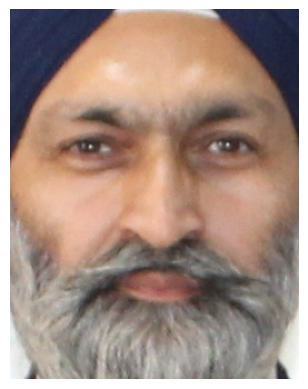

In [19]:
import matplotlib.pyplot as plt
faces = RetinaFace.extract_faces(img_path = "sample.jpg", align = True)
for face in faces:
  plt.imshow(face)
  plt.axis('off')
  plt.show()